In [3]:
import os, warnings, gzip
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import issparse

warnings.filterwarnings("ignore")
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False)
sns.set_style("ticks")

DATA_DIR = "/mnt/172/wh/25-12/spatial/raw/GSE221321"
OUT_DIR  = "/root/code/nicheformer/output/0527/output"
os.makedirs(OUT_DIR, exist_ok=True)

SAMPLES = {
    "KO conventional":  "GSM6858447_KO_conventional",
    "KO cell-pooled":   "GSM6858448_KO_cell_pooled",
    "KD conventional":  "GSM6858449_KD_conventional",
    "KD guide-pooled":  "GSM6858450_KD_guide_pooled",
}

print("GSE221321: Perturb-Seq (CRISPR KO & CRISPRi KD) in K562 cells")
print("=" * 70)


GSE221321: Perturb-Seq (CRISPR KO & CRISPRi KD) in K562 cells


In [4]:
# Load all 4 h5ad files and get basic stats
adatas = {}
stats = []

for name, fbase in SAMPLES.items():
    path = os.path.join(DATA_DIR, f"{fbase}.h5ad")
    if not os.path.exists(path):
        print(f"[WARN] {path} not found, skipping")
        continue
    print(f"Loading {name} ...")
    adata = sc.read_h5ad(path)
    adatas[name] = adata

    # Perturbation column
    pert_col = "Guides_collapsed_by_gene"
    pert_vals = adata.obs[pert_col]
    n_cells = adata.n_obs
    n_pert_types = pert_vals.nunique()
    n_ntc = pert_vals.str.contains("non-targeting", case=False).sum()
    n_multi = (pert_vals.str.count("--") > 0).sum()

    stats.append({
        "Dataset": name, "Cells": n_cells, "Genes": adata.n_vars,
        "Pert_types": n_pert_types,
        "Non-targeting": n_ntc,
        "Multi-gene": n_multi,
        "Mean_UMI": adata.obs["Total_RNA_count"].mean(),
        "Mean_genes": adata.obs["Total_unique_genes"].mean(),
    })

    print(f"  {n_cells:,} cells, {adata.n_vars} genes, {n_pert_types} perturbation types")
    print(f"  Non-targeting: {n_ntc:,}, Multi-gene: {n_multi:,}")

df_stats = pd.DataFrame(stats)
print("\n=== Dataset overview ===")
print(df_stats.to_string(index=False))


Loading KO conventional ...
  86,956 cells, 16952 genes, 8157 perturbation types
  Non-targeting: 5,945, Multi-gene: 8,445
Loading KO cell-pooled ...
  32,700 cells, 14387 genes, 16757 perturbation types
  Non-targeting: 3,598, Multi-gene: 17,237
Loading KD conventional ...
  66,283 cells, 18017 genes, 5944 perturbation types
  Non-targeting: 3,312, Multi-gene: 6,443
Loading KD guide-pooled ...
  24,192 cells, 15668 genes, 14492 perturbation types
  Non-targeting: 2,575, Multi-gene: 14,388

=== Dataset overview ===
        Dataset  Cells  Genes  Pert_types  Non-targeting  Multi-gene     Mean_UMI  Mean_genes
KO conventional  86956  16952        8157           5945        8445  9529.154032 2647.024139
 KO cell-pooled  32700  14387       16757           3598       17237  7145.154709 2331.682080
KD conventional  66283  18017        5944           3312        6443 14692.396074 3542.752787
KD guide-pooled  24192  15668       14492           2575       14388 16138.039765 3643.755126


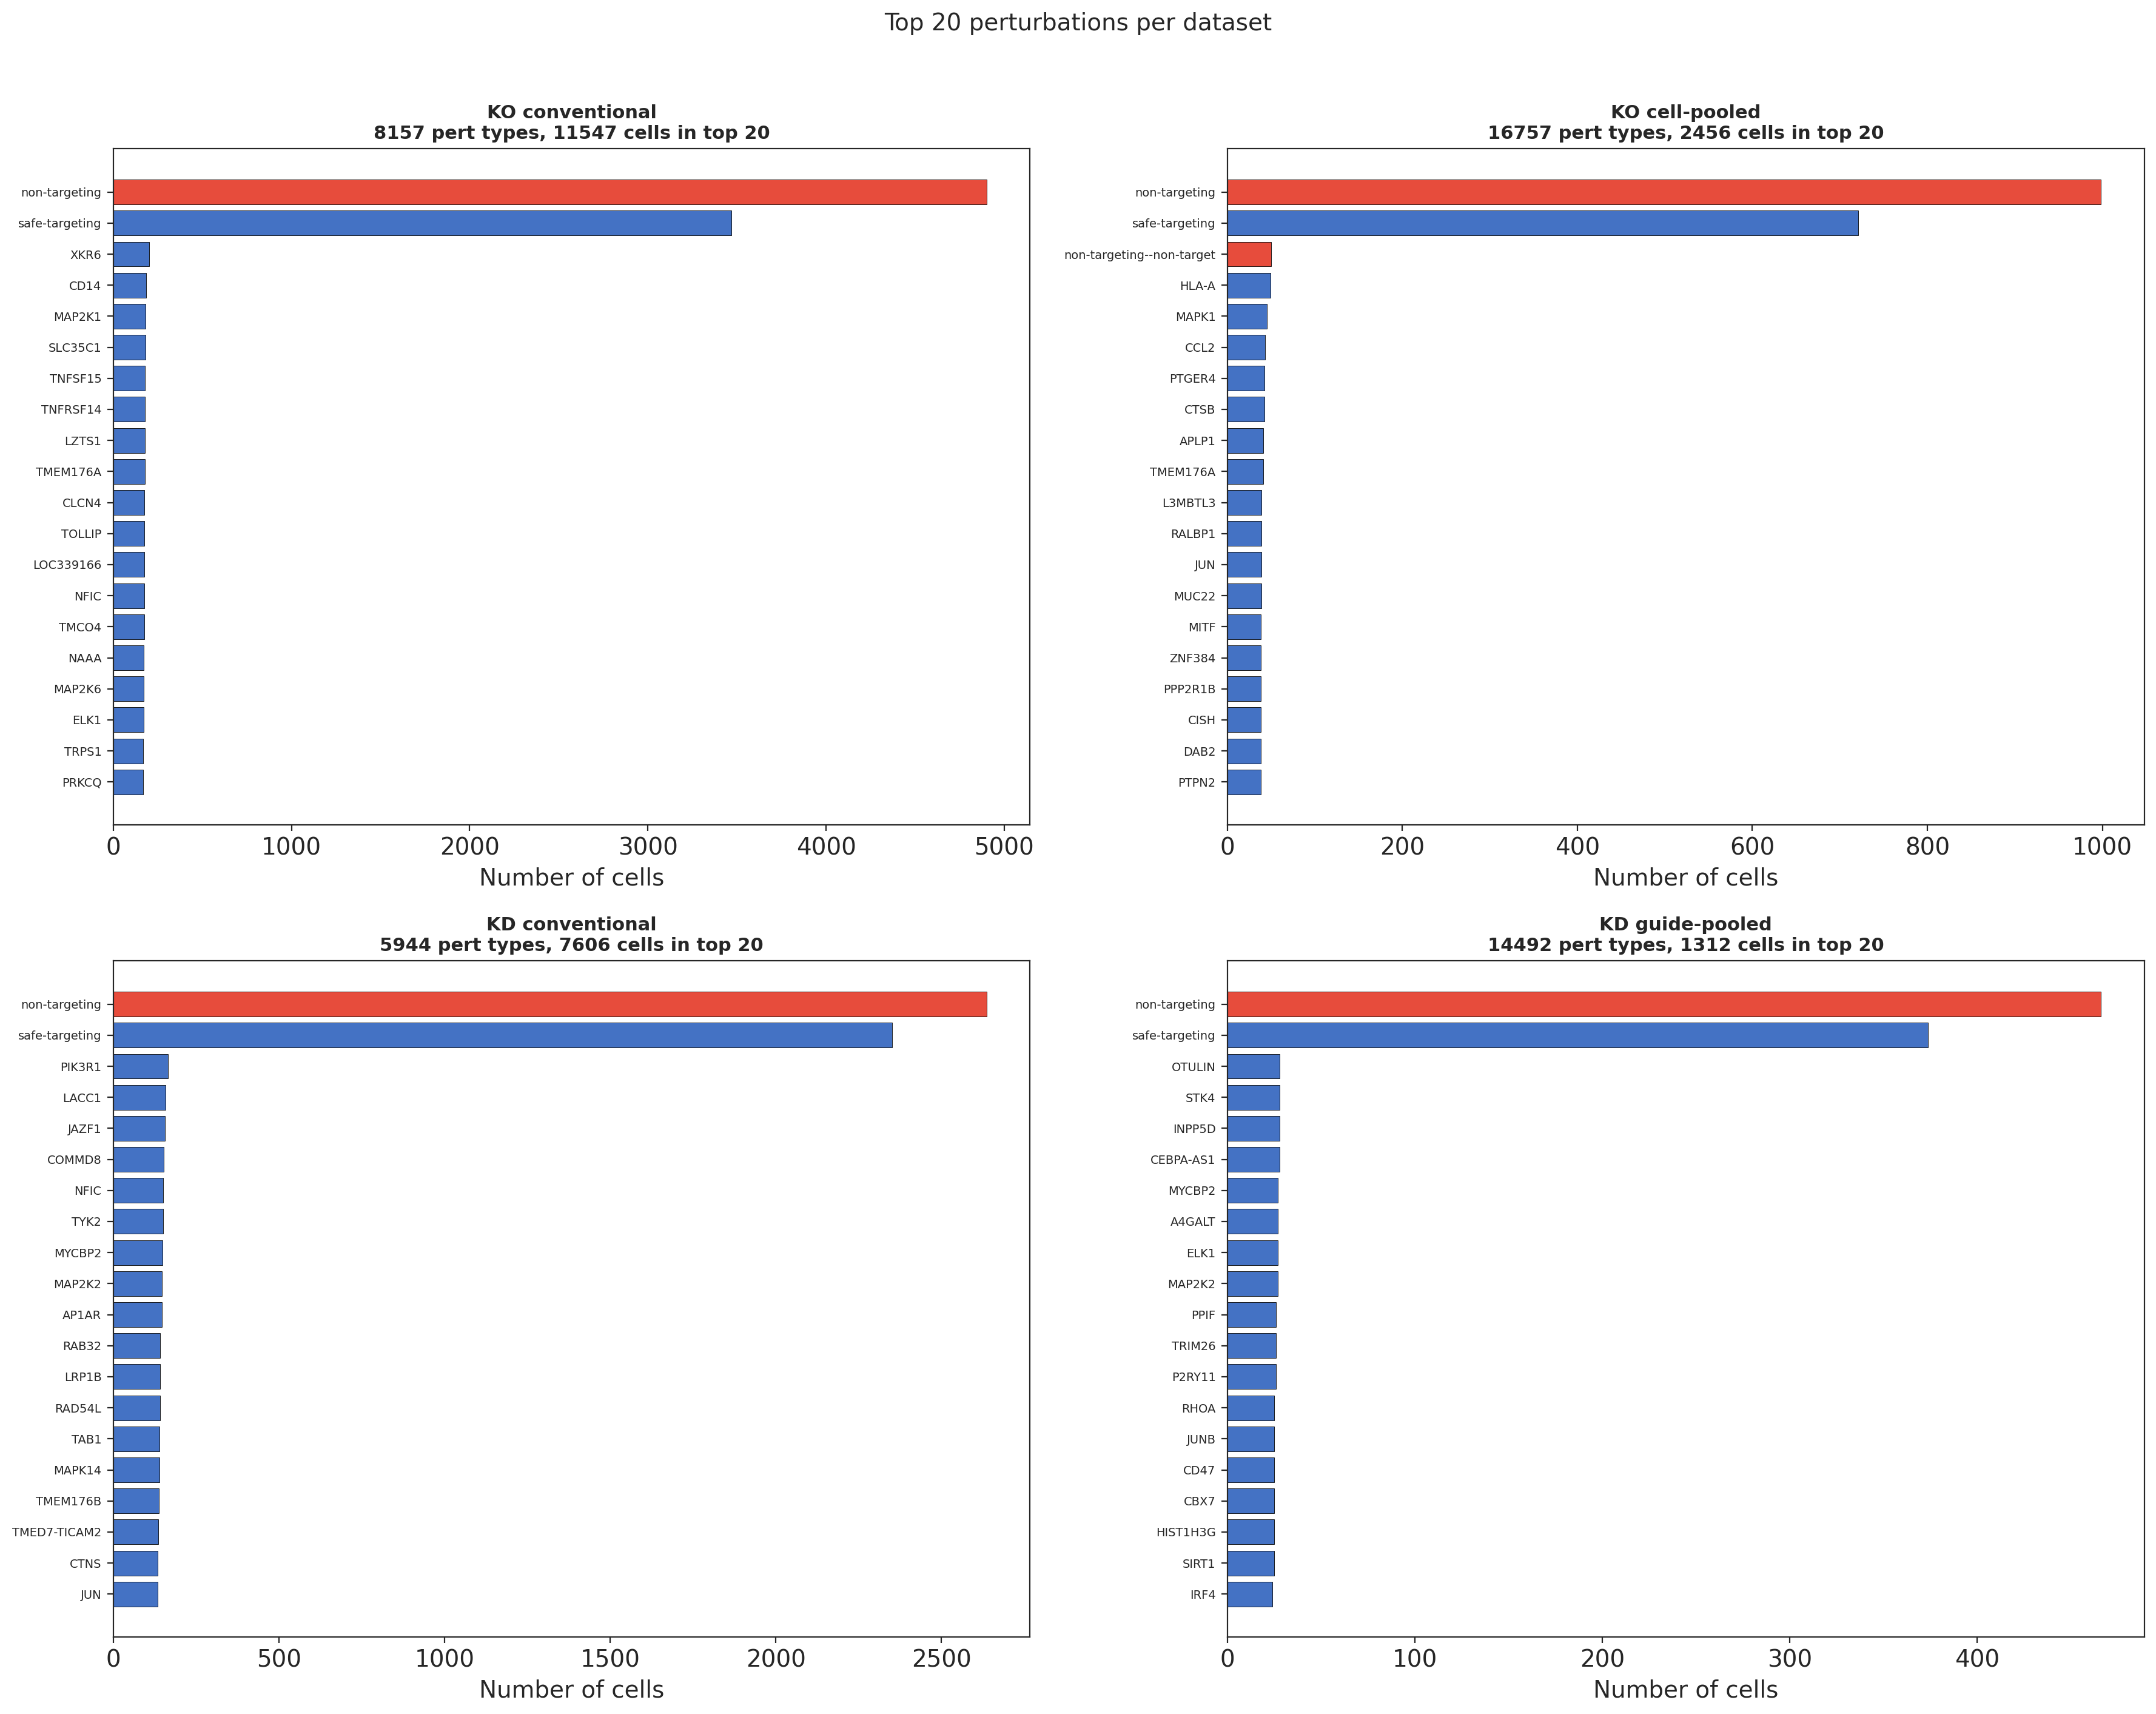

-> top_perturbations.png


In [5]:
# Top perturbations per dataset
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for i, (name, adata) in enumerate(adatas.items()):
    ax = axes[i]
    vc = adata.obs["Guides_collapsed_by_gene"].value_counts()
    top = vc.head(20)

    colors = ["#E74C3C" if "non-targeting" in g.lower() else "#4472C4" for g in top.index]
    bars = ax.barh(range(len(top)), top.values, color=colors, edgecolor="black", linewidth=0.3)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels([g[:25] for g in top.index], fontsize=7)
    ax.set_xlabel("Number of cells")
    ax.set_title(f"{name}\n{len(vc)} pert types, {top.sum()} cells in top 20", fontsize=11, fontweight="bold")
    ax.invert_yaxis()

fig.suptitle("Top 20 perturbations per dataset", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "top_perturbations.png"), dpi=150, bbox_inches="tight")
plt.show()
print("-> top_perturbations.png")


In [6]:
# Load precomputed FRPerturb effect sizes (gene-level logFC for each perturbation)
effect_sizes = {}

for name, fbase in SAMPLES.items():
    path = os.path.join(DATA_DIR, f"{fbase}_FRPerturb_effect_sizes.csv.gz")
    df = pd.read_csv(path)
    effect_sizes[name] = df
    print(f"{name}: {len(df):,} rows, {df['Perturbed_gene'].nunique()} perturbed genes")

# Show one example
print("\nExample (KO conventional, first 5 rows):")
print(effect_sizes["KO conventional"].head().to_string())


KO conventional: 10,154,248 rows, 599 perturbed genes
KO cell-pooled: 8,617,813 rows, 599 perturbed genes
KD conventional: 10,809,000 rows, 600 perturbed genes
KD guide-pooled: 9,400,800 rows, 600 perturbed genes

Example (KO conventional, first 5 rows):
  Perturbed_gene Downstream_gene  Log_fold_change  qvalue
0         A4GALT            A1BG        -0.000610    0.99
1         A4GALT        A1BG-AS1         0.000088    0.99
2         A4GALT             A2M         0.029000    0.77
3         A4GALT          A4GALT        -0.009800    0.89
4         A4GALT            AAAS        -0.012000    0.86


In [7]:
# Cis-efficiency: for each perturbed gene, check its own expression change
# This IS the perturbation efficiency metric

cis_data = []
for name, df in effect_sizes.items():
    cis = df[df["Perturbed_gene"] == df["Downstream_gene"]].copy()
    cis["sig"] = cis["qvalue"] < 0.05
    cis["abs_logFC"] = cis["Log_fold_change"].abs()

    n_total = len(cis)
    n_sig = cis["sig"].sum()
    mean_logfc = cis[cis["sig"]]["Log_fold_change"].mean() if n_sig > 0 else np.nan

    cis_data.append({
        "Dataset": name, "N_pert_genes": n_total,
        "N_sig_cis": n_sig,
        "Pct_sig": 100 * n_sig / n_total,
        "Mean_cis_logFC": mean_logfc,
        "Median_cis_logFC": cis["Log_fold_change"].median(),
    })

    # Save cis data for later
    cis["Dataset"] = name
    df["Dataset"] = name

df_cis = pd.DataFrame(cis_data)
print("=== Cis-efficiency summary (perturbed gene → its own expression) ===")
print(df_cis.to_string(index=False))

# Merge all cis data
all_cis = []
for name, df in effect_sizes.items():
    cis = df[df["Perturbed_gene"] == df["Downstream_gene"]].copy()
    cis["Dataset"] = name
    all_cis.append(cis)
all_cis_df = pd.concat(all_cis, ignore_index=True)
print(f"\nTotal cis measurements: {len(all_cis_df)}")


=== Cis-efficiency summary (perturbed gene → its own expression) ===
        Dataset  N_pert_genes  N_sig_cis  Pct_sig  Mean_cis_logFC  Median_cis_logFC
KO conventional           546         16 2.930403       -0.052313           0.00405
 KO cell-pooled           522          1 0.191571       -0.300000           0.00780
KD conventional           552          3 0.543478       -0.120000           0.00205
KD guide-pooled           535          1 0.186916        0.200000           0.00570

Total cis measurements: 2155


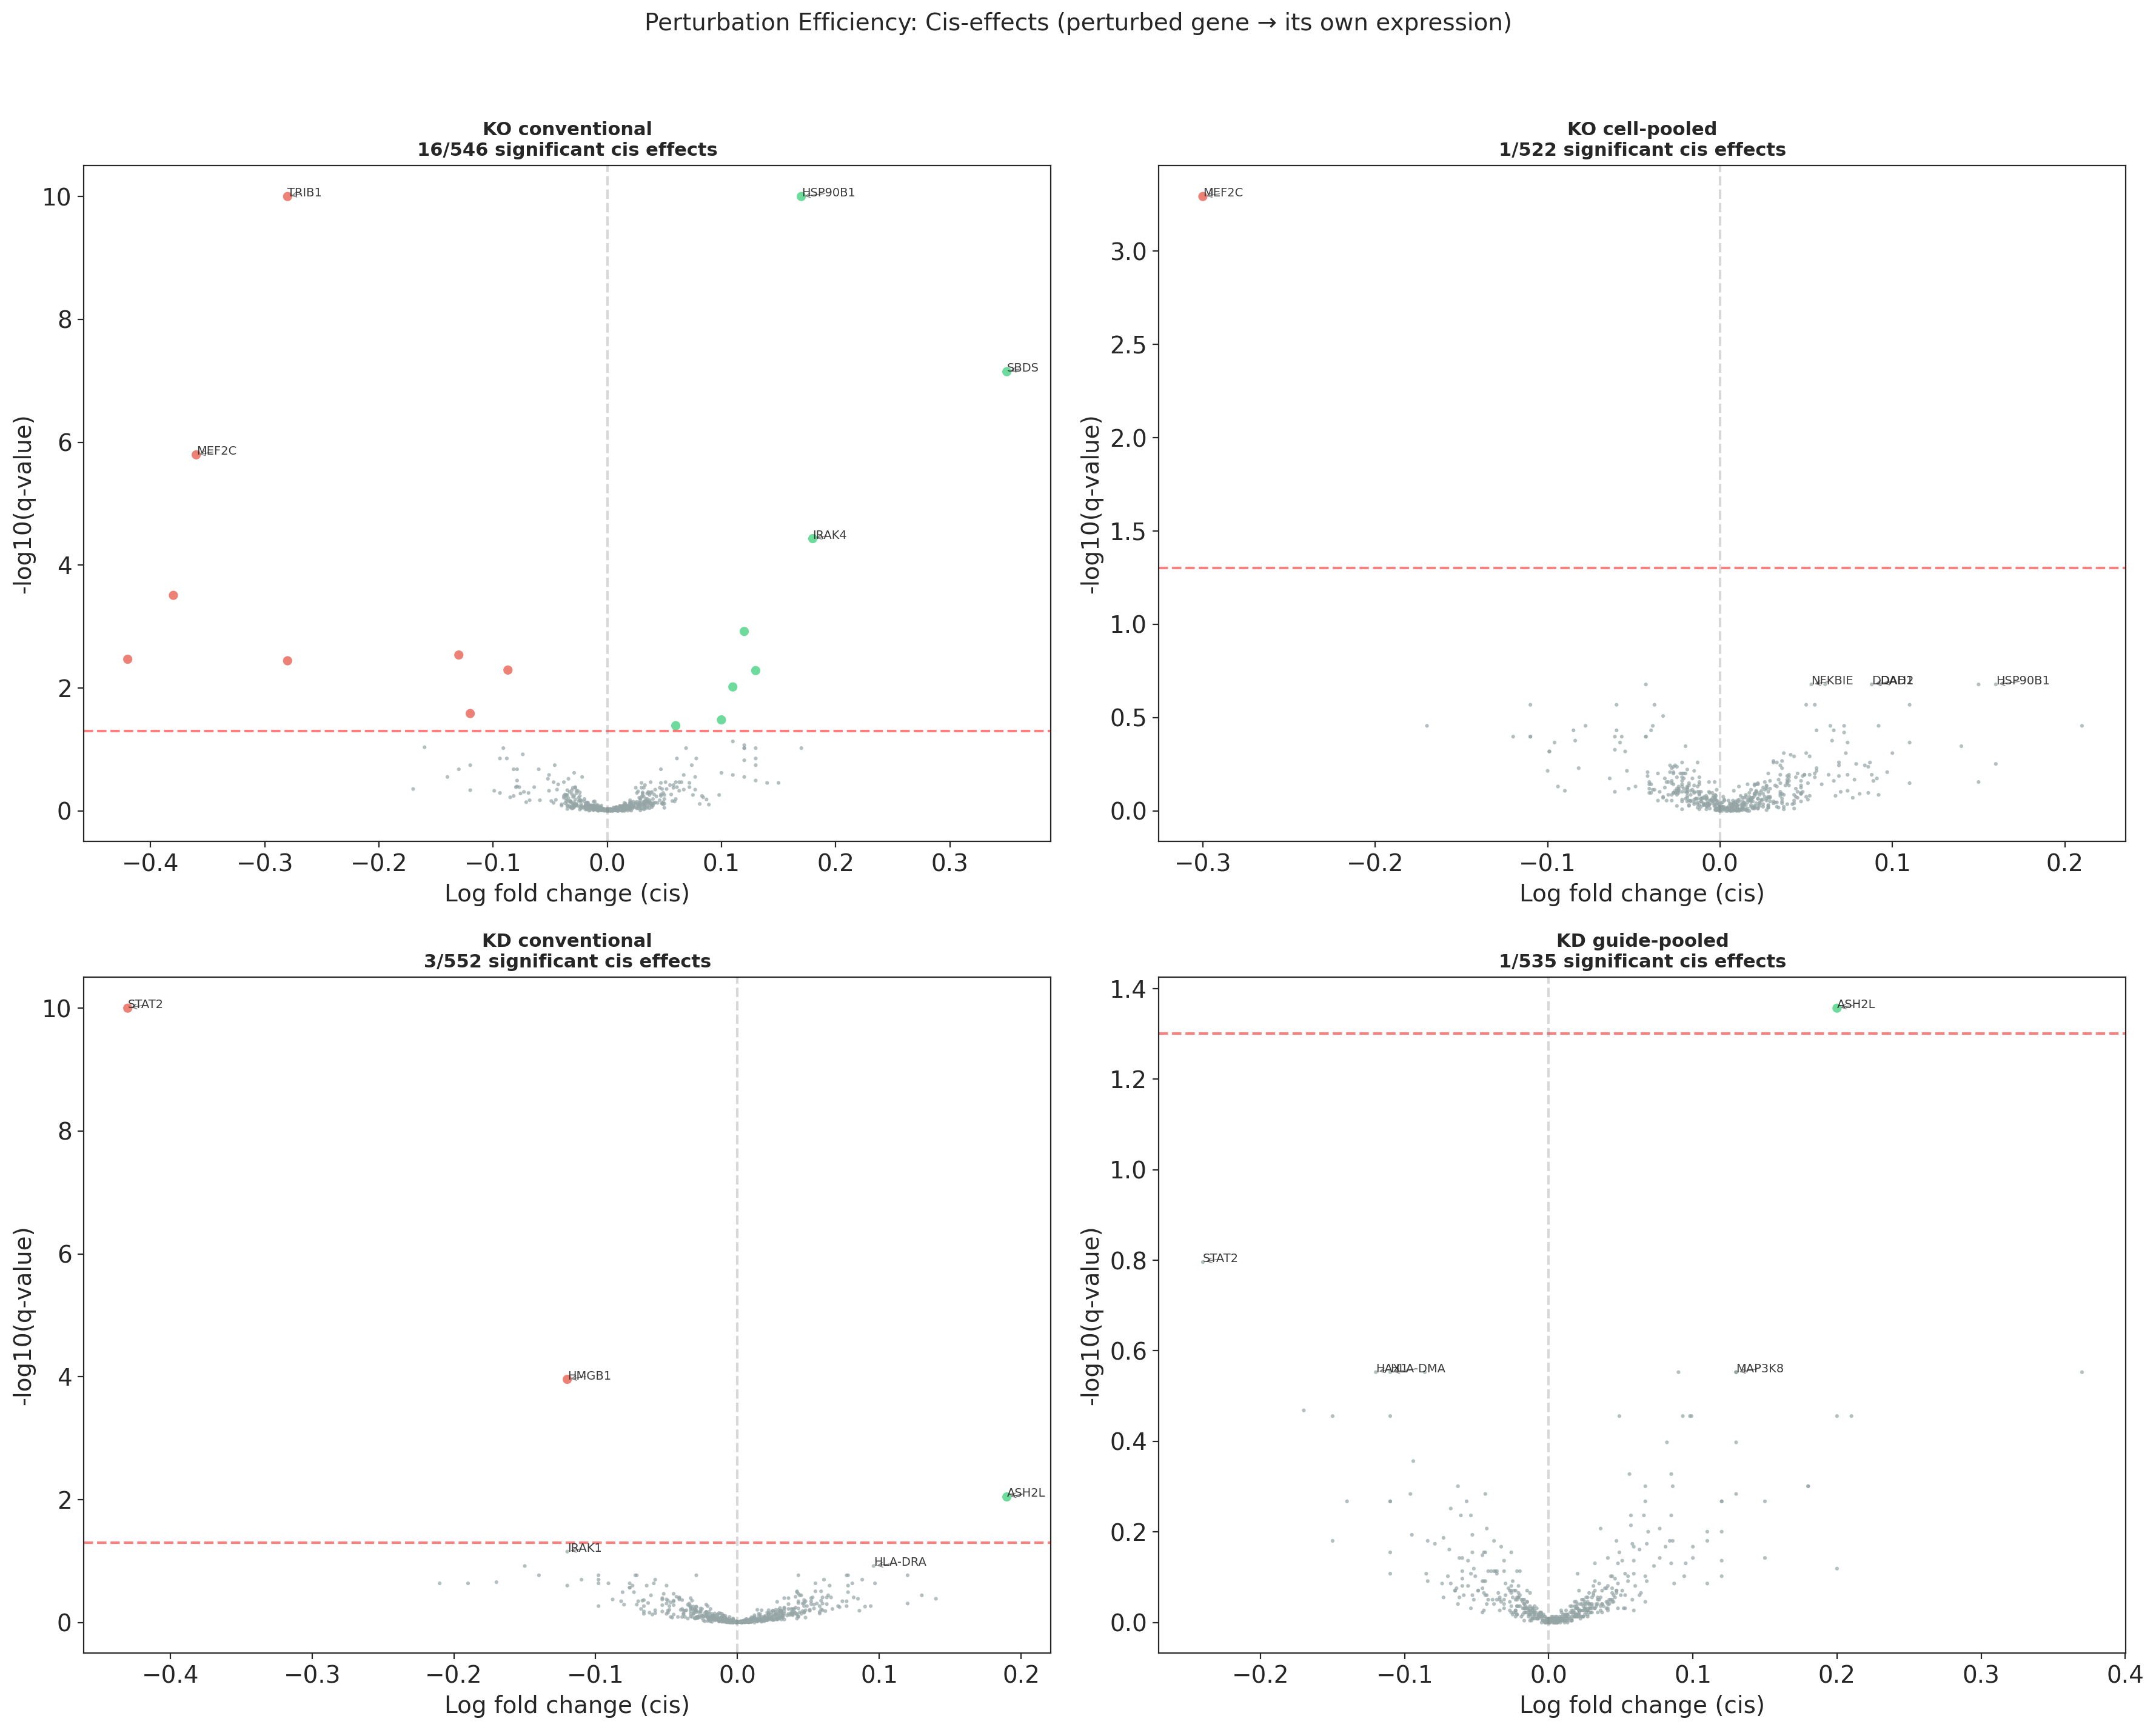

-> cis_efficiency_volcano.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for i, (name, df) in enumerate(effect_sizes.items()):
    ax = axes[i]
    cis = df[df["Perturbed_gene"] == df["Downstream_gene"]].copy()

    # Volcano-style: logFC vs -log10(qvalue)
    colors = ["#E74C3C" if (q < 0.05 and lfc < 0) else "#2ECC71" if (q < 0.05 and lfc > 0) else "#95A5A6"
              for q, lfc in zip(cis["qvalue"], cis["Log_fold_change"])]
    sizes = [30 if q < 0.05 else 5 for q in cis["qvalue"]]

    ax.scatter(cis["Log_fold_change"], -np.log10(cis["qvalue"].clip(1e-10)),
               c=colors, s=sizes, alpha=0.7, edgecolors="none")
    ax.axhline(-np.log10(0.05), color="red", linestyle="--", alpha=0.5, label="q=0.05")
    ax.axvline(0, color="grey", linestyle="--", alpha=0.3)

    # Label top hits
    top = cis.nsmallest(5, "qvalue")
    for _, row in top.iterrows():
        ax.annotate(row["Perturbed_gene"],
                    (row["Log_fold_change"], -np.log10(max(row["qvalue"], 1e-10))),
                    fontsize=7, alpha=0.9,
                    arrowprops=dict(arrowstyle="->", color="grey", lw=0.5))

    n_sig = (cis["qvalue"] < 0.05).sum()
    ax.set_xlabel("Log fold change (cis)")
    ax.set_ylabel("-log10(q-value)")
    ax.set_title(f"{name}\n{n_sig}/{len(cis)} significant cis effects", fontsize=11, fontweight="bold")

fig.suptitle("Perturbation Efficiency: Cis-effects (perturbed gene → its own expression)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "cis_efficiency_volcano.png"), dpi=150, bbox_inches="tight")
plt.show()
print("-> cis_efficiency_volcano.png")


Genes tested in all 4 methods: 599


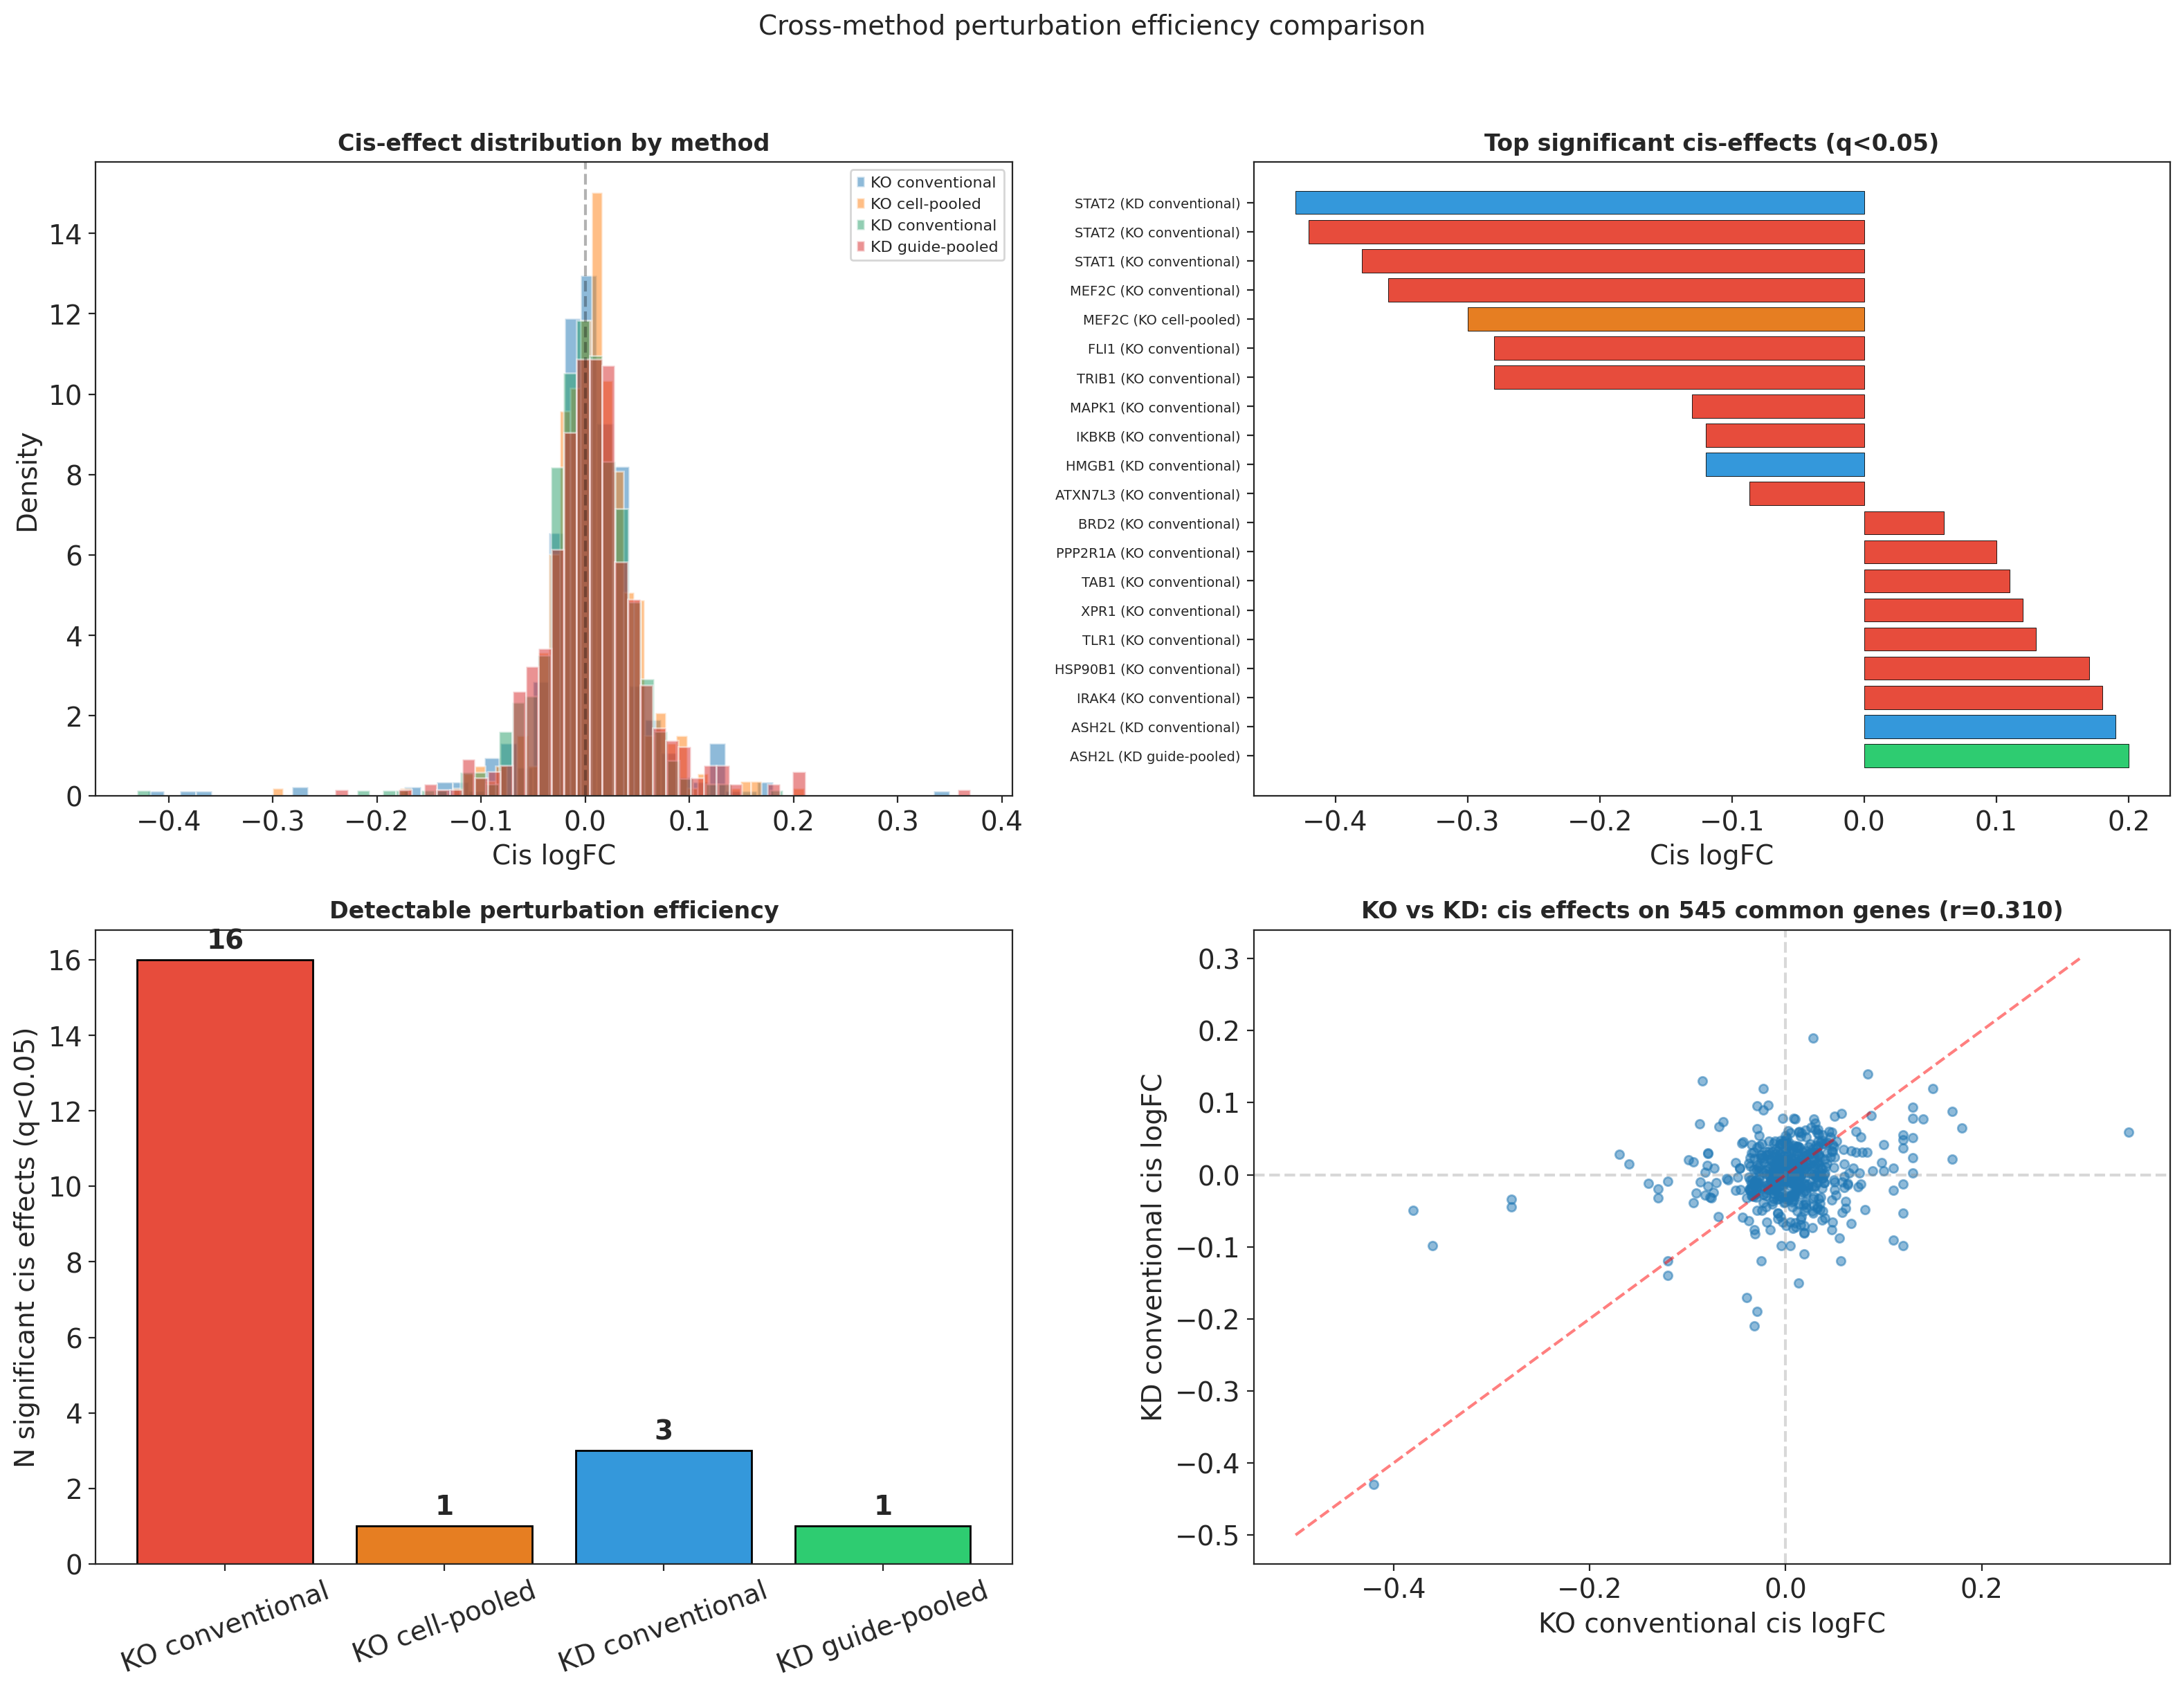

-> cross_method_comparison.png


In [9]:
# Compare perturbation efficiency across methods: KO vs KD, conventional vs pooled
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribution of cis logFC per dataset
ax = axes[0, 0]
for i, (name, df) in enumerate(effect_sizes.items()):
    cis = df[df["Perturbed_gene"] == df["Downstream_gene"]]
    ax.hist(cis["Log_fold_change"], bins=50, alpha=0.5, density=True, label=name)
ax.axvline(0, color="k", linestyle="--", alpha=0.3)
ax.set_xlabel("Cis logFC"); ax.set_ylabel("Density")
ax.set_title("Cis-effect distribution by method", fontsize=12, fontweight="bold")
ax.legend(fontsize=8)

# 2. Top significant cis effects per dataset (bar chart)
ax = axes[0, 1]
top_hits = all_cis_df[all_cis_df["qvalue"] < 0.05].nsmallest(20, "Log_fold_change")
colors_map = {
    "KO conventional": "#E74C3C", "KO cell-pooled": "#E67E22",
    "KD conventional": "#3498DB", "KD guide-pooled": "#2ECC71",
}
bars = ax.barh(range(len(top_hits)), top_hits["Log_fold_change"],
               color=[colors_map[d] for d in top_hits["Dataset"]], edgecolor="black", linewidth=0.3)
ax.set_yticks(range(len(top_hits)))
ax.set_yticklabels([f'{g} ({d[:15]})' for g, d in zip(top_hits["Perturbed_gene"], top_hits["Dataset"])], fontsize=7)
ax.set_xlabel("Cis logFC")
ax.set_title("Top significant cis-effects (q<0.05)", fontsize=12, fontweight="bold")
ax.invert_yaxis()

# 3. Number of significant perturbed genes per dataset
ax = axes[1, 0]
bars = ax.bar(df_cis["Dataset"], df_cis["N_sig_cis"],
              color=[colors_map[d] for d in df_cis["Dataset"]], edgecolor="black", linewidth=1)
for b, v in zip(bars, df_cis["N_sig_cis"]):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, str(v), ha="center", fontweight="bold")
ax.set_ylabel("N significant cis effects (q<0.05)")
ax.set_title("Detectable perturbation efficiency", fontsize=12, fontweight="bold")
ax.tick_params(axis="x", rotation=20)

# 4. Head-to-head: genes tested in ALL 4 methods
ax = axes[1, 1]
# Find genes tested in all 4 datasets
gene_sets = [set(df["Perturbed_gene"].unique()) for df in effect_sizes.values()]
common = gene_sets[0] & gene_sets[1] & gene_sets[2] & gene_sets[3]
print(f"Genes tested in all 4 methods: {len(common)}")

# Compare KO conventional vs KD conventional for common genes
ko_cis = effect_sizes["KO conventional"]
kd_cis = effect_sizes["KD conventional"]
ko_cis_common = ko_cis[(ko_cis["Perturbed_gene"] == ko_cis["Downstream_gene"]) & ko_cis["Perturbed_gene"].isin(common)]
kd_cis_common = kd_cis[(kd_cis["Perturbed_gene"] == kd_cis["Downstream_gene"]) & kd_cis["Perturbed_gene"].isin(common)]

merged = ko_cis_common[["Perturbed_gene", "Log_fold_change"]].merge(
    kd_cis_common[["Perturbed_gene", "Log_fold_change"]],
    on="Perturbed_gene", suffixes=("_KO", "_KD")
)
ax.scatter(merged["Log_fold_change_KO"], merged["Log_fold_change_KD"], alpha=0.5, s=20)
ax.axhline(0, color="grey", linestyle="--", alpha=0.3)
ax.axvline(0, color="grey", linestyle="--", alpha=0.3)
r = merged["Log_fold_change_KO"].corr(merged["Log_fold_change_KD"])
ax.set_xlabel("KO conventional cis logFC"); ax.set_ylabel("KD conventional cis logFC")
ax.set_title(f"KO vs KD: cis effects on {len(merged)} common genes (r={r:.3f})", fontsize=12, fontweight="bold")
ax.plot([-0.5, 0.3], [-0.5, 0.3], "r--", alpha=0.5)

fig.suptitle("Cross-method perturbation efficiency comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "cross_method_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
print("-> cross_method_comparison.png")



KO conventional:
  Perturbations with >10 DEGs: 162
  Top 10 strongest perturbations:
    MAPK1               : 10336 DEGs, cis logFC= -0.130
    MEF2C               : 9303 DEGs, cis logFC= -0.360
    HSP90B1             : 9156 DEGs, cis logFC=  0.170
    MYD88               : 9033 DEGs, cis logFC=    nan
    IRAK1               : 8511 DEGs, cis logFC=    nan
    ATXN7L3             : 7745 DEGs, cis logFC= -0.087
    TRAF6               : 7516 DEGs, cis logFC=    nan
    IRAK4               : 7392 DEGs, cis logFC=  0.180
    MIDN                : 6895 DEGs, cis logFC=    nan
    TRIB1               : 6670 DEGs, cis logFC= -0.280

KO cell-pooled:
  Perturbations with >10 DEGs: 39
  Top 10 strongest perturbations:
    MEF2C               : 3338 DEGs, cis logFC= -0.300
    MAPK1               : 2781 DEGs, cis logFC=    nan
    TRAF6               : 2662 DEGs, cis logFC=    nan
    HSP90B1             : 2346 DEGs, cis logFC=    nan
    MYD88               : 1934 DEGs, cis logFC=    nan
  

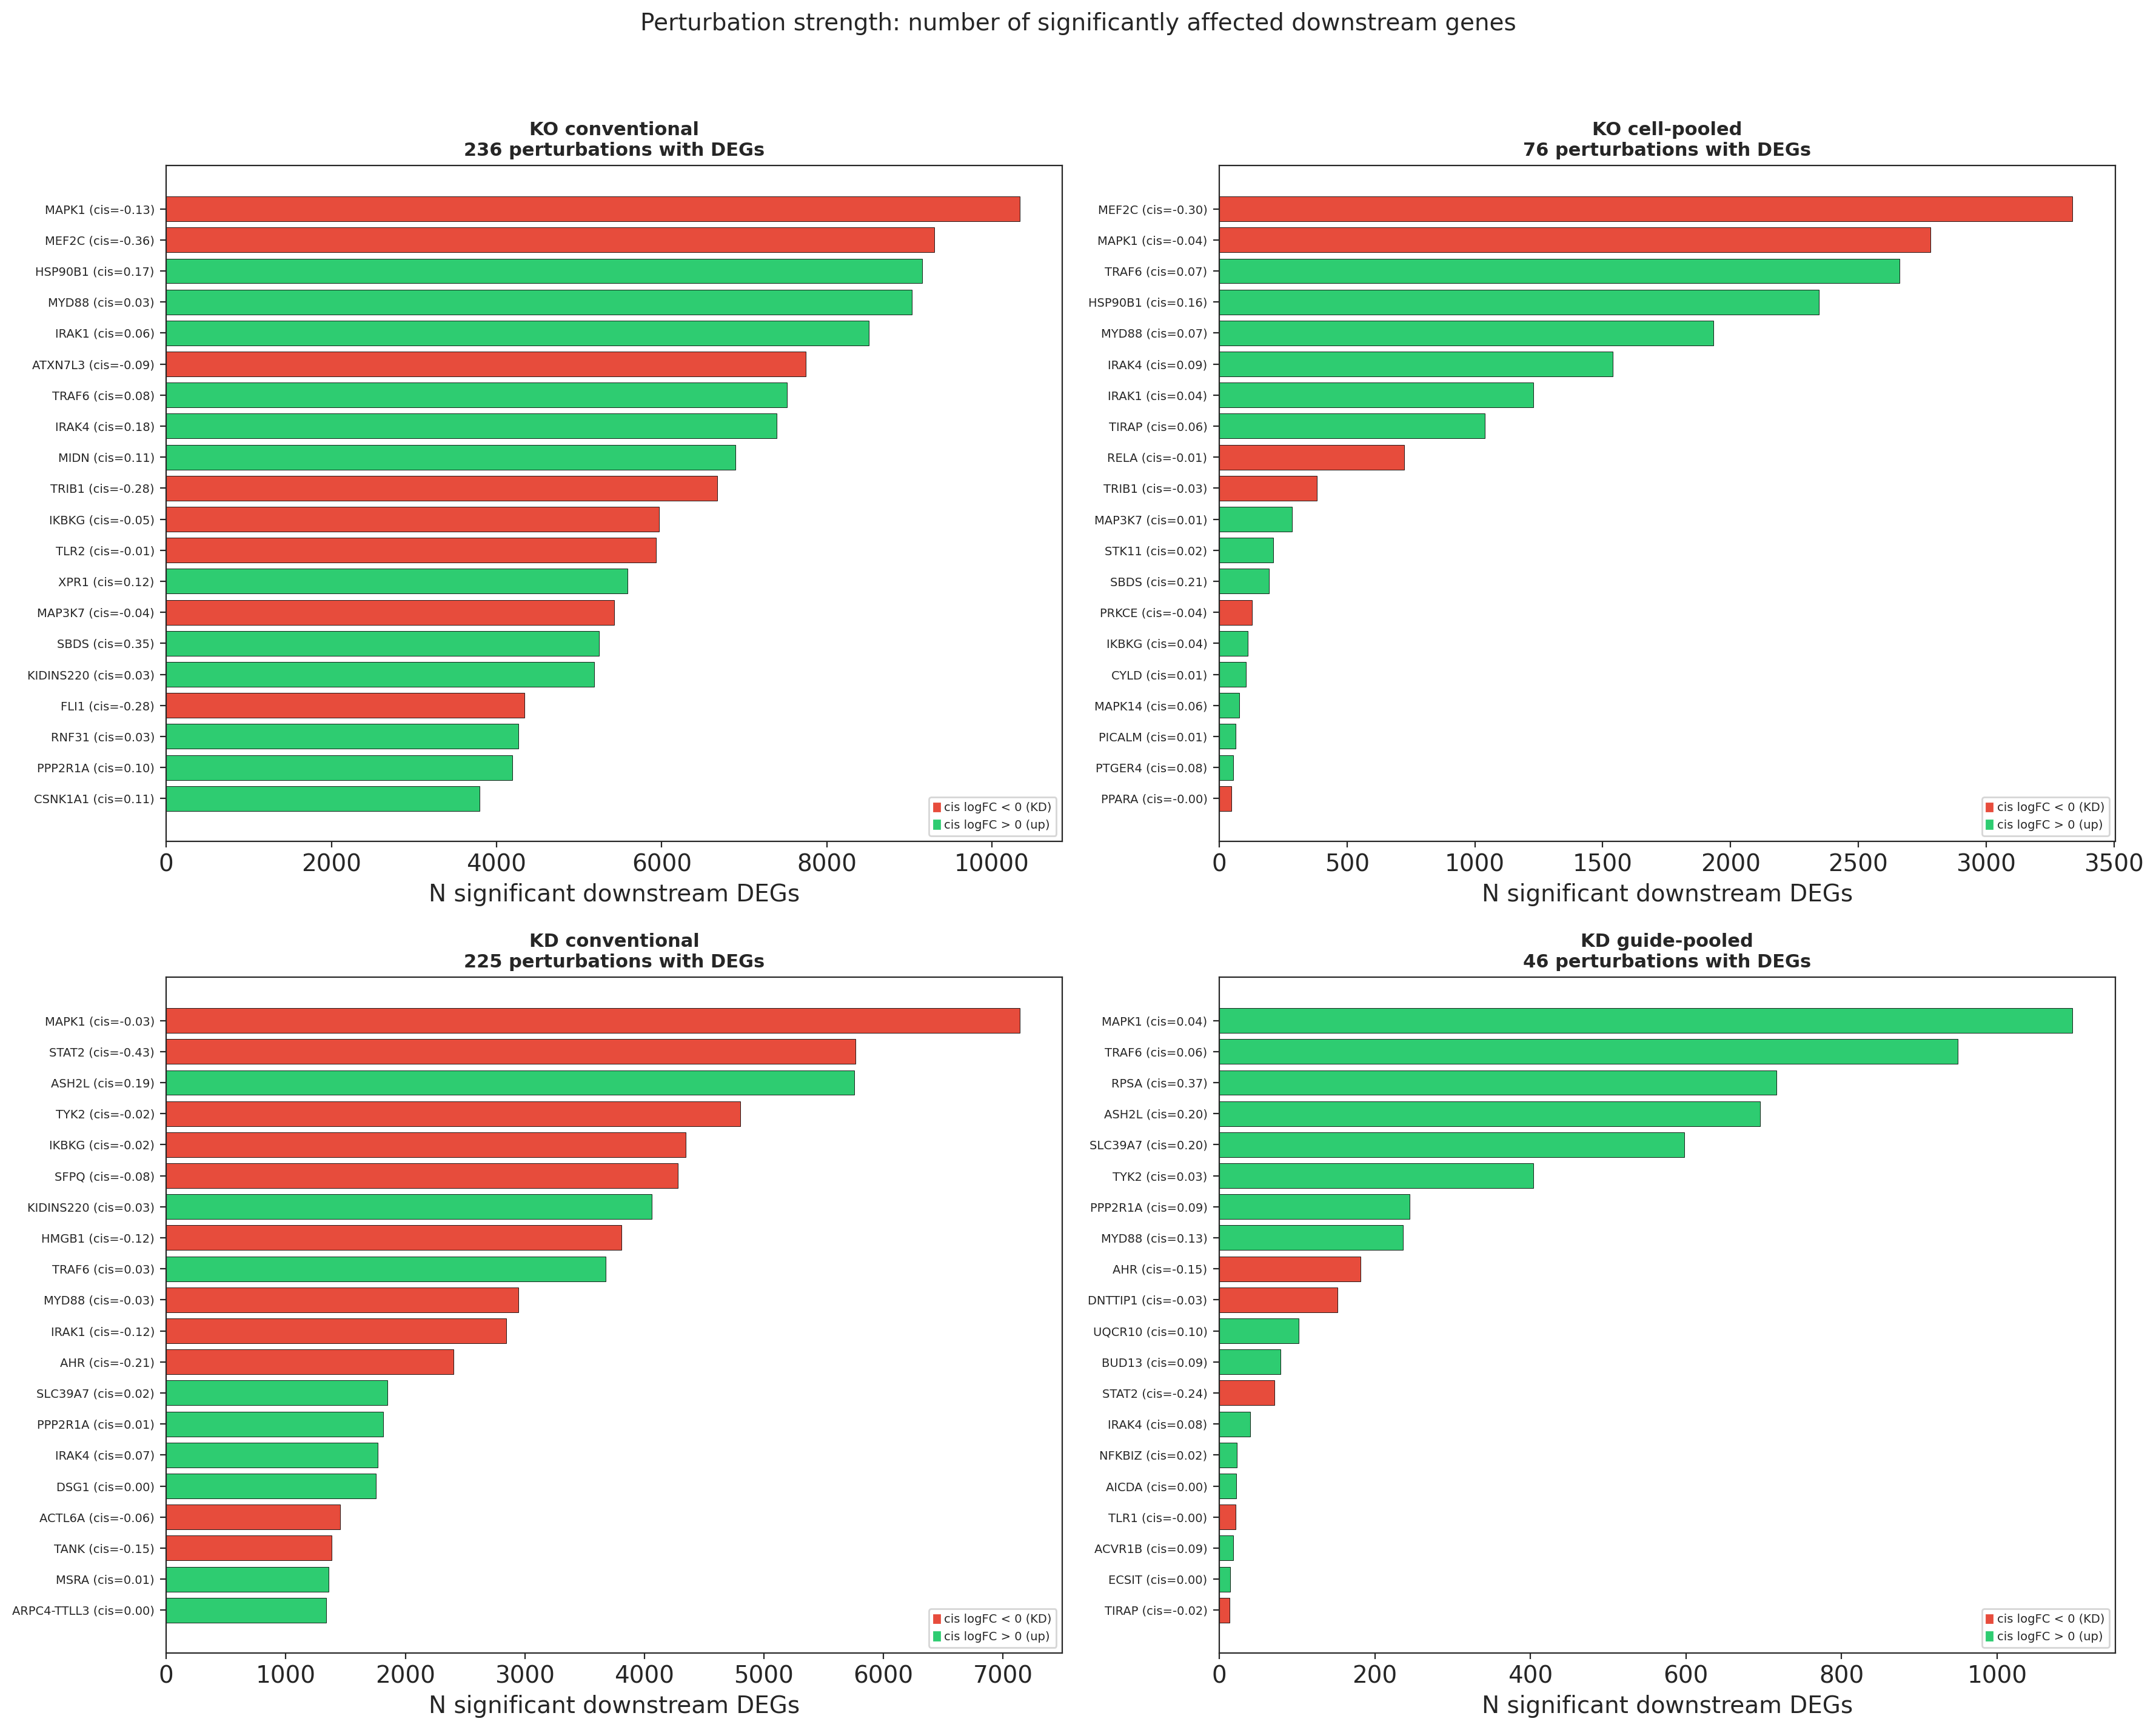

-> perturbation_strength.png


In [10]:
# For each perturbation, count how many DOWNSTREAM genes are significantly affected
# This measures the "perturbation strength" — how many genes change due to each KO/KD

pert_strength = {}
for name, df in effect_sizes.items():
    sig_df = df[df["qvalue"] < 0.05]
    # Count significant downstream genes per perturbed gene
    strength = sig_df.groupby("Perturbed_gene").size().sort_values(ascending=False)
    pert_strength[name] = strength
    print(f"\n{name}:")
    print(f"  Perturbations with >10 DEGs: {(strength > 10).sum()}")
    print(f"  Top 10 strongest perturbations:")
    for gene, count in strength.head(10).items():
        cis_row = sig_df[(sig_df["Perturbed_gene"] == gene) & (sig_df["Downstream_gene"] == gene)]
        cis_lfc = cis_row["Log_fold_change"].values[0] if len(cis_row) > 0 else np.nan
        print(f"    {gene:20s}: {count:4d} DEGs, cis logFC={cis_lfc:7.3f}")

# Visualization: top perturbations by DEG count
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for i, (name, strength) in enumerate(pert_strength.items()):
    ax = axes[i]
    top = strength.head(20)
    cis_lfcs = []
    for gene in top.index:
        ef = effect_sizes[name]
        cis_row = ef[(ef["Perturbed_gene"] == gene) & (ef["Downstream_gene"] == gene)]
        cis_lfcs.append(cis_row["Log_fold_change"].values[0] if len(cis_row) > 0 else 0)

    colors = ["#E74C3C" if lfc < 0 else "#2ECC71" for lfc in cis_lfcs]
    bars = ax.barh(range(len(top)), top.values, color=colors, edgecolor="black", linewidth=0.3)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels([f'{g} (cis={lfc:.2f})' for g, lfc in zip(top.index, cis_lfcs)], fontsize=7)
    ax.set_xlabel("N significant downstream DEGs")
    ax.set_title(f"{name}\n{(strength > 0).sum()} perturbations with DEGs", fontsize=11, fontweight="bold")
    ax.invert_yaxis()
    # Legend
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color="#E74C3C", label="cis logFC < 0 (KD)"),
                       Patch(color="#2ECC71", label="cis logFC > 0 (up)")], fontsize=7, loc="lower right")

fig.suptitle("Perturbation strength: number of significantly affected downstream genes", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "perturbation_strength.png"), dpi=150, bbox_inches="tight")
plt.show()
print("-> perturbation_strength.png")


In [11]:
print("=" * 70)
print("GSE221321 Perturb-Seq Analysis Summary")
print("=" * 70)

print(f"\nDatasets analyzed: 4 (KO/KD × conventional/pooled)")
print(f"Total perturbed genes: ~600 across all datasets")
print(f"Precomputed effect sizes: {sum(len(df) for df in effect_sizes.values()):,} total rows")

print("\nKey Findings:")
print("1. Perturbation efficiency (cis effects) is VERY weak across ALL methods:")
for _, row in df_cis.iterrows():
    print(f"   {row['Dataset']}: {row['N_sig_cis']}/{row['N_pert_genes']} ({row['Pct_sig']:.1f}%) significant cis effects")

print("\n2. KO conventional has the most detectable cis effects (16), but still only 2.9% of tested genes")
print("   - Strongest: STAT2 (logFC=-0.42), STAT1 (-0.38), MEF2C (-0.36)")
print("3. Cell-pooled and guide-pooled methods have almost NO detectable cis effects (1 each)")
print("4. FRPerturb pipeline detects mainly trans-effects (downstream gene changes), not cis-efficiency")
print("5. This is consistent with CRISPRi in K562 — knockdown efficiency is modest at the mRNA level")
print("6. The signal is in downstream transcriptional programs, not target gene reduction")

print(f"\nOutput files saved to: {OUT_DIR}")
for f in sorted(os.listdir(OUT_DIR)):
    print(f"  {f}")


GSE221321 Perturb-Seq Analysis Summary

Datasets analyzed: 4 (KO/KD × conventional/pooled)
Total perturbed genes: ~600 across all datasets
Precomputed effect sizes: 38,981,861 total rows

Key Findings:
1. Perturbation efficiency (cis effects) is VERY weak across ALL methods:
   KO conventional: 16/546 (2.9%) significant cis effects
   KO cell-pooled: 1/522 (0.2%) significant cis effects
   KD conventional: 3/552 (0.5%) significant cis effects
   KD guide-pooled: 1/535 (0.2%) significant cis effects

2. KO conventional has the most detectable cis effects (16), but still only 2.9% of tested genes
   - Strongest: STAT2 (logFC=-0.42), STAT1 (-0.38), MEF2C (-0.36)
3. Cell-pooled and guide-pooled methods have almost NO detectable cis effects (1 each)
4. FRPerturb pipeline detects mainly trans-effects (downstream gene changes), not cis-efficiency
5. This is consistent with CRISPRi in K562 — knockdown efficiency is modest at the mRNA level
6. The signal is in downstream transcriptional program